#  단백질 딥러닝 (Protein Deep Learning)
작성: David Ricardo Figueroa Blanco

## Colab에서 실행하기

이 노트북은 Google Colab에서 실행하는 것을 권장합니다. 아래 Colab 배지를 클릭하면 바로 열립니다. (Kaggle에서도 열 수 있습니다.)

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/isg-yhlee93/lecture/blob/main/Modeling%20Proteins/1_Protein_Deep_Learning.ipynb)
[![Open In Kaggle](https://kaggle.com/static/images/open-in-kaggle.svg)](https://www.kaggle.com/kernels/welcome?src=https://github.com/isg-yhlee93/lecture/blob/main/Modeling%20Proteins/1_Protein_Deep_Learning.ipynb)


이 튜토리얼에서는 원-핫 인코딩(one-hot encoder)이나 아미노산 조성(aminoacid composition) 같은 단백질 서열 특징화(featurization) 방법을 비교합니다. DeepChem과 추가 패키지들을 사용하여, 단백질의 녹는 온도(melting temperature, 단백질 안정성을 잘 나타내는 지표)를 예측하는 모델을 만들겠습니다.

단백질의 녹는 온도(MT)는 단백질 안정성의 척도입니다. 이 값은 다양한 실험 조건에 따라 달라질 수 있지만, 잘 정리된(curated) 데이터베이스를 문헌(https://aip.scitation.org/doi/10.1063/1.4947493)에서 찾을 수 있습니다. 이 논문에서는 단백질의 다양한 열역학적 정보를 제공하므로, 단백질 안정성 연구에 유용한 자원이 됩니다. 단백질 안정성과 관련된 또 다른 정보로는, 돌연변이(mutation)로 인한 깁스 자유 에너지(Gibbs Free Energy)의 변화 $\Delta \Delta G°$ 가 있습니다.

단백질 안정성 연구는 단백질 공학(protein engineering)과 생체촉매(biocatalysis) 같은 분야에서 중요합니다. 촉매 효율(catalytic efficiency)이 연구 대상 단백질의 3차 구조(tertiary structure)와 직접적으로 관련될 수 있기 때문입니다.


# 설치(Setup)

아래 셀을 실행하여 DeepChem과 필요한 패키지(openmm, pdbfixer, propy3)를 설치합니다.


In [ ]:
!pip install -qq --pre deepchem
!pip install -qq openmm pdbfixer biopython propy3   # openmm·pdbfixer: PDB 다운로드/수선, biopython: 서열 추출, propy3: 아미노산 조성

# 불필요한 경고·로그 메시지 끄기 (화면을 깔끔하게 보기 위함)
import warnings
warnings.filterwarnings('ignore')
from rdkit import RDLogger
RDLogger.DisableLog('rdApp.*')


# 데이터 추출


이 셀에서는 논문 https://aip.scitation.org/doi/10.1063/1.4947493 에 발표된 데이터셋을 DeepChem 데이터셋 저장소에서 내려받습니다.


In [ ]:
import deepchem as dc 
import os 
from deepchem.utils import download_url
data_dir = dc.utils.get_data_dir()
# 단백질 열역학 데이터셋(CSV)을 내려받습니다.
download_url("https://deepchemdata.s3-us-west-1.amazonaws.com/datasets/pucci-proteins-appendixtable1.csv",dest_dir=data_dir)
print('데이터셋을 다음 경로에 내려받았습니다: {}'.format(data_dir))
dataset_file = os.path.join(data_dir, "pucci-proteins-appendixtable1.csv")


데이터셋을 자세히 살펴봅니다. 각 연구 대상 단백질의 PDB id와 해당 돌연변이, 그리고 열역학적 성질의 변화가 담겨 있습니다.


In [3]:
import pandas as pd 
data = pd.read_csv(dataset_file)
data


,Unnamed: 0,N,PDBid,Chain,RESN,RESwt,RESmut,ΔTmexp,Tmexp [wt],ΔΔHmexp,...,ΔΔGexp(T),T,Nres,R (Å),Protein,Organism,Ref.,pH,Exp.Tech.,
0,NaN,1,1aky,A,8,VAL,ILE,-1.5,47.6,70,...,5.0,25,220,1.63,ADK,Yeast,[1],[7.5],FL,NaN
1,NaN,2,1aky,A,48,GLN,GLU,-1.3,47.6,60,...,4.0,25,220,1.63,ADK,Yeast,[1],[7.7],FL,NaN
2,NaN,3,1aky,A,77,THR,HIS,-1.1,47.6,130,...,9.0,25,220,1.63,ADK,Yeast,[1],[7.5],FL,NaN
3,NaN,4,1aky,A,110,THR,HIS,-4.8,47.6,165,...,11.0,25,220,1.63,ADK,Yeast,[1],[7.6],FL,NaN
4,NaN,5,1aky,A,169,ASN,ASP,-0.6,47.6,140,...,9.0,25,220,1.63,ADK,Yeast,[1],[7.5],FL,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1621,NaN,1622,5pti_m52l,A,15,LYS,SER,-1.3,91.7,-5,...,1.2,25,58,1.00,PTI M52L,Bovine,[232],[3.0],DSC,NaN
1622,NaN,1623,5pti_m52l,A,15,LYS,THR,-1.1,91.7,-9,...,-3.6,25,58,1.00,PTI M52L,Bovine,[232],[3.0],DSC,NaN
1623,NaN,1624,5pti_m52l,A,15,LYS,VAL,-6.3,91.7,4,...,4.7,25,58,1.00,PTI M52L,Bovine,[232],[3.0],DSC,NaN
1624,NaN,1625,5pti_m52l,A,15,LYS,TRP,-7.5,91.7,17,...,8.5,25,58,1.00,PTI M52L,Bovine,[232],[2.5],DSC,NaN


여기서는 고유한 PDB id와 그에 해당하는 녹는 온도만 담은 작은 데이터프레임을 추출합니다.


In [4]:
WT_Tm = data[['PDBid','Tmexp [wt]']]
WT_Tm.set_index('PDBid',inplace=True)


In [5]:
WT_Tm


,Tmexp [wt]
PDBid,
1aky,47.6
1aky,47.6
1aky,47.6
1aky,47.6
1aky,47.6
...,...
5pti_m52l,91.7
5pti_m52l,91.7
5pti_m52l,91.7


여기서는 각 단백질의 PDB id를 키(key)로, 야생형(wild type) 녹는 온도를 값(value)으로 하는 딕셔너리를 만듭니다.


In [6]:
dict_WT_TM = {}
for k,v in WT_Tm.itertuples():
    if(k not in dict_WT_TM):
        dict_WT_TM[k]=float(v)


여기서는 A 사슬(chain A)에만 돌연변이가 보고된 단백질들을 추출합니다.


In [7]:
pdbs = data[data['PDBid'].str.len()<5]
pdbs = pdbs[pdbs['Chain'] == "A"]


In [8]:
pdbs[['RESN','RESwt','RESmut']]


,RESN,RESwt,RESmut
0,8,VAL,ILE
1,48,GLN,GLU
2,77,THR,HIS
3,110,THR,HIS
4,169,ASN,ASP
...,...,...,...
1604,36,GLY,ALA
1605,36,GLY,SER
1606,37,GLY,ALA
1607,39,ARG,ALA


이 셀은 전체 돌연변이 수와 녹는 온도 변화를 추출합니다. 또한 딕셔너리를 사용해 잔기(residue) 돌연변이를 한 글자 코드(one letter code)로 변환합니다.


In [10]:
alls=[]
for resnum,wt in pdbs[['RESN','RESwt','RESmut','PDBid','ΔTmexp']].items():
    alls.append(wt.values)
# 아미노산 3글자 코드 -> 1글자 코드 변환 딕셔너리
d = {'CYS': 'C', 'ASP': 'D', 'SER': 'S', 'GLN': 'Q', 'LYS': 'K',
     'ILE': 'I', 'PRO': 'P', 'THR': 'T', 'PHE': 'F', 'ASN': 'N', 
     'GLY': 'G', 'HIS': 'H', 'LEU': 'L', 'ARG': 'R', 'TRP': 'W', 
     'ALA': 'A', 'VAL':'V', 'GLU': 'E', 'TYR': 'Y', 'MET': 'M'}
resnum=alls[0]
wt=[d[x.strip()] for x in alls[1]]   # 야생형 아미노산(1글자 코드)
mut=[d[x.strip()] for x in alls[2]]  # 돌연변이 아미노산(1글자 코드)
codes=alls[3]  # PDB 코드
tms=alls[4]    # 녹는 온도


In [11]:
print("pdbid {}, WT-AA {}, Resnum {}, MUT-AA {}, DeltaTm {}".format(codes[0],wt[0],resnum[0],mut[0],tms[0]))


pdbid 1aky, WT-AA V, Resnum 8, MUT-AA I,DeltaTm -1.5


# PDB 다운로드


여기서는 pdbfixer 도구를 사용해 PDB id별로 모든 단백질 구조를 내려받습니다.


In [13]:
from pdbfixer import PDBFixer
from openmm.app import PDBFile


In [ ]:
!mkdir PDBs


pdbfixer의 fixer를 사용해 각 단백질을 PDB 코드로 내려받고, Protein Data Bank 파일에 흔히 있는 문제들을 수선(fix)합니다. 이 과정은 약 15분이 걸리고 100MB 정도를 사용합니다.
PDBFixer 사용법은 https://htmlpreview.github.io/?https://github.com/openmm/pdbfixer/blob/master/Manual.html 에서 확인할 수 있습니다. 여기서는 PDB 코드로 pdb 파일을 내려받은 뒤, 비표준(nonstandard) 또는 누락된(missing) 잔기 찾기, 누락된 원자 채우기 같은 정제(curation)를 수행합니다.


In [ ]:
import os 
import time
t0 = time.time()

downloaded = os.listdir("PDBs")
PDBs_ids= set(pdbs['PDBid'])
pdb_list = []
print("다운로드 시작")
for pdbid in PDBs_ids:
    name=pdbid+".pdb"
    if(name in downloaded):
        continue
    try:
        # PDB 코드로 구조를 내려받고 흔한 문제들을 수선합니다.
        fixer = PDBFixer(pdbid=pdbid)
        fixer.findMissingResidues()        # 누락된 잔기 찾기
        fixer.findNonstandardResidues()    # 비표준 잔기 찾기
        fixer.replaceNonstandardResidues() # 비표준 잔기 치환
        fixer.removeHeterogens(True)       # 이종분자(물 등) 제거
        fixer.findMissingAtoms()           # 누락된 원자 찾기
        fixer.addMissingAtoms()            # 누락된 원자 추가
        PDBFile.writeFile(fixer.topology, fixer.positions, open('./PDBs/%s.pdb' % (pdbid), 'w'),keepIds=True)
    except:
        print("문제 발생: {}".format(pdbid))
print("총 소요 시간 {}".format(time.time()-t0))


다음 함수는 `A###B` 표기(A=야생형 아미노산, ###=위치, B=새 아미노산)로 나타낸 서열을 돌연변이시키는 데 도움을 줍니다.


In [17]:
import re
def MutateSeq(seq,Mutant):
    """
    Mutant 문자열을 기준으로 서열을 돌연변이시킵니다. 표기법은 다음과 같습니다:
    A###B  (A=야생형 아미노산, ###=위치, B=돌연변이 아미노산)
    """
    aalist = re.findall('([A-Z])([0-9]+)([A-Z])', Mutant)
    
    #(len(aalist)==1):
    newseq=seq
    listseq=list(newseq)
    for aas in aalist:
        wildAA = aas[0]
        pos = int(aas[1]) -1
        if(pos >= len(listseq)):
            print("돌연변이 위치가 단백질 범위를 벗어났습니다")
            return None
        MutAA = aas[-1]
        
        if(listseq[pos]==wildAA):
            
            listseq[pos]=MutAA
            
        else:
            #print("야생형 아미노산이 일치하지 않습니다")
            return None
    return("".join(listseq))


다음 함수는 PDB 구조를 기반으로 아미노산 서열을 식별하는 데 도움을 줍니다.


In [18]:
from Bio.PDB.PDBParser import PDBParser
from Bio.PDB.Polypeptide import PPBuilder
ppb=PPBuilder()
def GetSeqFromPDB(pdbid):
    structure = PDBParser().get_structure(pdbid.split(".")[0], 'PDBs/{}'.format(pdbid))
    seqs=[]
    return ppb.build_peptides(structure)


앞서 설명한 함수들의 예시입니다.
GetSeqFromPDB: 앞에서 내려받은 pdb 하나를 받아 서열을 1글자 코드로 추출합니다.


In [19]:
import warnings; warnings.simplefilter('ignore')
test="1ezm"
print(test)
seq = GetSeqFromPDB("{}.pdb".format(test))[0].get_sequence()
print("원본 서열")
print(seq)


1ezm
Original Sequence
AEAGGPGGNQKIGKYTYGSDYGPLIVNDRCEMDDGNVITVDMNSSTDDSKTTPFRFACPTNTYKQVNGAYSPLNDAHFFGGVVFKLYRDWFGTSPLTHKLYMKVHYGRSVENAYWDGTAMLFGDGATMFYPLVSLDVAAHEVSHGFTEQNSGLIYRGQSGGMNEAFSDMAGEAAEFYMRGKNDFLIGYDIKKGSGALRYMDQPSRDGRSIDNASQYYNGIDVHHSSGVYNRAFYLLANSPGWDTRKAFEVFVDANRYYWTATSNYNSGACGVIRSAQNRNYSAADVTRAFSTVGVTCPSAL


돌연변이에 대한 정보


In [20]:
informSeq=GetSeqFromPDB(test+".pdb")[0].__repr__()
print("서열 정보",informSeq)
start = re.findall('[0-9]+',informSeq)[0]
print("보고된 돌연변이 {}{}{}".format("R",179,"A"))
numf =179 - int(start) + 1  # 음수 잔기 번호 등의 경우를 보정


Seq information <Polypeptide start=1 end=301>
Reported Mutation R179A


서열에 적용된 돌연변이


In [21]:
mutfinal = "R{}A".format(numf)
print("실제 돌연변이 = ",mutfinal)
mutseq = MutateSeq(seq,mutfinal)
print(mutseq)


Real Mutation =  R179A
AEAGGPGGNQKIGKYTYGSDYGPLIVNDRCEMDDGNVITVDMNSSTDDSKTTPFRFACPTNTYKQVNGAYSPLNDAHFFGGVVFKLYRDWFGTSPLTHKLYMKVHYGRSVENAYWDGTAMLFGDGATMFYPLVSLDVAAHEVSHGFTEQNSGLIYRGQSGGMNEAFSDMAGEAAEFYMAGKNDFLIGYDIKKGSGALRYMDQPSRDGRSIDNASQYYNGIDVHHSSGVYNRAFYLLANSPGWDTRKAFEVFVDANRYYWTATSNYNSGACGVIRSAQNRNYSAADVTRAFSTVGVTCPSAL


이 for 루프에서는 데이터셋에 있는 모든 단백질의 서열을 추출합니다. 또한 돌연변이된 서열을 만들고 녹는 온도 변화를 덧붙입니다. 일부 경우 pdb의 결손(gap) 때문에 MutateSeq 함수가 실패할 수 있는데, 그런 항목은 건너뜁니다. 이 단계는 전체 과정에서 중요합니다. 서열과 녹는 온도(우리의 레이블)를 담은 최종 표 형태의 데이터를 만들기 때문입니다.


In [ ]:
import os

information = {}
count = 1
failures=[]
for code,tm,numr,wt_val,mut_val in zip(codes,tms,resnum,wt,mut):
    count += 1
    # 위 다운로드 단계에서 받지 못한(수선 실패한) PDB는 건너뜁니다.
    if not os.path.exists("PDBs/{}.pdb".format(code)):
        failures.append((code, "PDB 파일 없음"))
        continue
    seq = GetSeqFromPDB("{}.pdb".format(code))[0].get_sequence()
    mutfinal="WT"
    if("{}-{}".format(code,mutfinal) not in information):
        informSeq=GetSeqFromPDB(code+".pdb")[0].__repr__()
        start = re.findall('[-0-9]+',informSeq)[0]
    if(int(start)<0):
        numf =numr - int(start)      # start가 음수면 0은 잔기 번호로 쓰이지 않음
    else:
        numf =numr - int(start) + 1 
    mutfinal = "{}{}{}".format(wt_val,numf,mut_val)
    mutseq = MutateSeq(seq,mutfinal)
    if(mutseq==None):
        failures.append((code,mutfinal))
        continue
    # 키: "코드-돌연변이", 값: [돌연변이 서열, 녹는 온도 변화]
    information["{}-{}".format(code,mutfinal)]=[mutseq,dict_WT_TM[code]-float(tm)]


# 단백질 서열을 이용한 딥러닝·머신러닝 모델


In [23]:
import deepchem as dc
import torch.nn as nn
import torch


여기서는 두 개의 리스트, 즉 서열(데이터)과 녹는 온도(레이블)를 추출합니다.


In [24]:
seq_list=[]
deltaTm=[]
for i in information.values():
    seq_list.append(i[0])
    deltaTm.append(i[1])


In [25]:
max_seq= 0 
for i in seq_list:
    if(len(i)>max_seq):
        max_seq=len(i)  # 가장 긴 서열의 길이


여기서는 OneHotFeaturizer를 사용해 단백질 서열을 숫자 배열로 변환합니다.


In [26]:
codes = ['A', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'K', 'L',
         'M', 'N', 'P', 'Q', 'R', 'S', 'T', 'V', 'W', 'Y']
# 20개 아미노산을 원-핫으로, 최대 길이는 max_seq로 패딩합니다.
OneHotFeaturizer = dc.feat.OneHotFeaturizer(codes,max_length=max_seq)
features = OneHotFeaturizer.featurize(seq_list)


OneHotFeaturizer는 각 서열에 대한 원-핫 벡터를 담은 행렬을 만든다는 점에 주목하세요.


In [27]:
features_vector  = []
for i in range(len(features)):
    features_vector.append(features[i].flatten())  # 2차원 원-핫 행렬을 1차원 벡터로 펼침


In [28]:
dc_dataset = dc.data.NumpyDataset(X=features_vector,y=deltaTm)


In [29]:
dc_dataset


<NumpyDataset X.shape: (1488, 13188), y.shape: (1488,), w.shape: (1488,), task_names: [0]>

여기서는 데이터셋을 학습/테스트로 나누기 위한 분할기(splitter)를 만듭니다.


In [30]:
from deepchem import splits
splitter = splits.RandomSplitter()
train, test  = splitter.train_test_split(dc_dataset,seed=42)


회귀 결과를 평가하기 위해, PyTorch로 신경망을 만들고 손실 함수로 "MAE"(평균 절대 오차)를 사용합니다.


In [49]:
import torch.optim as optim
import torch.nn.functional as F
import matplotlib.pyplot as plt
import pandas as pd

# 모델 정의 (은닉층 2개 + 드롭아웃)
class ProteinModel(nn.Module):
    def __init__(self, input_size):
        super(ProteinModel, self).__init__()
        self.fc1 = nn.Linear(input_size, 32)
        self.dropout1 = nn.Dropout(0.2)
        self.fc2 = nn.Linear(32, 32)
        self.dropout2 = nn.Dropout(0.2)
        self.fc3 = nn.Linear(32, 1)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = self.dropout1(x)
        x = F.relu(self.fc2(x))
        x = self.dropout2(x)
        x = self.fc3(x)
        return x

input_size = train.X.shape[1]  
model = ProteinModel(input_size)


Epoch [1/30], Train Loss: 59.8350, Val Loss: 61.0038
Epoch [2/30], Train Loss: 51.4501, Val Loss: 53.2404
Epoch [3/30], Train Loss: 42.1209, Val Loss: 38.0507
Epoch [4/30], Train Loss: 18.6921, Val Loss: 13.0056
Epoch [5/30], Train Loss: 15.8223, Val Loss: 11.1212
Epoch [6/30], Train Loss: 14.8701, Val Loss: 9.4398
Epoch [7/30], Train Loss: 16.6456, Val Loss: 9.0781
Epoch [8/30], Train Loss: 13.1553, Val Loss: 7.4179
Epoch [9/30], Train Loss: 13.4347, Val Loss: 6.9786
Epoch [10/30], Train Loss: 12.7587, Val Loss: 7.1300
Epoch [11/30], Train Loss: 12.4871, Val Loss: 6.9377
Epoch [12/30], Train Loss: 12.3102, Val Loss: 6.5128
Epoch [13/30], Train Loss: 11.6099, Val Loss: 7.5611
Epoch [14/30], Train Loss: 14.1950, Val Loss: 6.7952
Epoch [15/30], Train Loss: 10.5894, Val Loss: 6.1077
Epoch [16/30], Train Loss: 13.2864, Val Loss: 6.8252
Epoch [17/30], Train Loss: 11.8302, Val Loss: 6.4149
Epoch [18/30], Train Loss: 10.8937, Val Loss: 6.6818
Epoch [19/30], Train Loss: 10.8588, Val Loss: 5.96

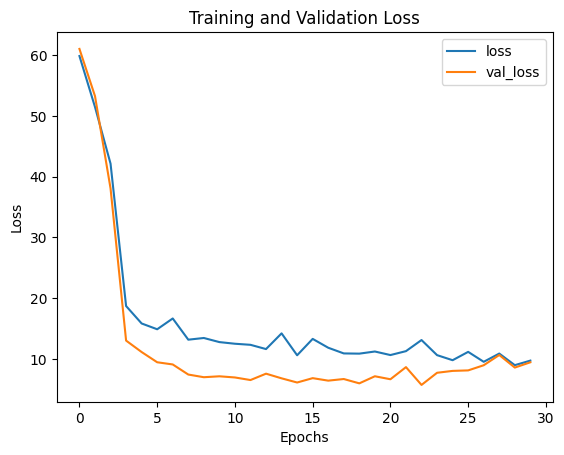

In [48]:
criterion = nn.L1Loss()  # 평균 절대 오차(MAE) 손실
optimizer = optim.Adam(model.parameters(), lr=0.001)

# 그래프를 위해 손실 기록을 저장
train_losses = []
val_losses = []

# 학습 루프
num_epochs = 30
batch_size = 100
for epoch in range(num_epochs):
    model.train()
    permutation = torch.randperm(train.X.shape[0])  # 배치 학습을 위해 인덱스를 섞음
    for i in range(0, train.X.shape[0], batch_size):
        indices = permutation[i:i + batch_size]
        batch_x = torch.tensor(train.X[indices], dtype=torch.float32)
        batch_y = torch.tensor(train.y[indices], dtype=torch.float32).view(-1, 1)

        optimizer.zero_grad()
        outputs = model(batch_x)
        loss = criterion(outputs, batch_y)

        loss.backward()
        optimizer.step()

    train_losses.append(loss.item())

    # 검증 손실 계산
    model.eval()
    with torch.no_grad():
        val_x = torch.tensor(test.X, dtype=torch.float32)
        val_y = torch.tensor(test.y, dtype=torch.float32).view(-1, 1)
        val_outputs = model(val_x)
        val_loss = criterion(val_outputs, val_y)
        val_losses.append(val_loss.item())

    print(f'Epoch [{epoch+1}/{num_epochs}], Train Loss: {loss.item():.4f}, Val Loss: {val_loss.item():.4f}')

# 손실 곡선 그리기
history_df = pd.DataFrame({
    'loss': train_losses,
    'val_loss': val_losses
})
history_df[['loss', 'val_loss']].plot()
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.show()


# DeepChem TorchModel 모델


DeepChem의 `TorchModel`을 사용하면, 앞서 만든 PyTorch 모델을 그대로 감싸 DeepChem 모델로 학습·평가할 수 있습니다.


In [51]:
model_dc = dc.models.TorchModel(model, dc.models.losses.L1Loss())
model_dc.fit(train)


10.934407043457032

In [52]:
# 딥러닝(DeepChem TorchModel)을 MAE와 R2로 평가합니다.
mae_metric = dc.metrics.Metric(dc.metrics.mae_score)
r2_metric  = dc.metrics.Metric(dc.metrics.pearson_r2_score)
dl_score = model_dc.evaluate(test, [mae_metric, r2_metric])
print("딥러닝(OneHot) 테스트 점수:", dl_score)


test dataset R2: {'pearson_r2_score': 0.6921896004241516}


# 고전적 머신러닝 모델 예시


마지막으로, 아미노산 조성(AAcomposition)이나 아미노산의 조성·전이·분포(Composition, transition, distribution) (https://www.pnas.org/content/92/19/8700) 같은 다른 기술자(descriptor)들과 비교해 봅니다.


In [49]:
from propy import PyPro


다음 셀에서는 단백질 서열을 기반으로 PyPro 객체를 만듭니다. PyPro를 사용하면 아미노산 조성 벡터를 계산할 수 있습니다.
여기서는 앞 모델에서 사용한 각 서열에 대해 아미노산 조성 벡터의 리스트를 만듭니다.


In [50]:
import numpy as np 
aaComplist = []
CTDList =[]
for seq in seq_list:
    Obj = PyPro.GetProDes(seq)
    aaComplist.append(np.array(list(Obj.GetAAComp().values())))  # 아미노산 조성(AAComp)
    CTDList.append(np.array(list(Obj.GetCTD().values())))        # 조성·전이·분포(CTD)


In [51]:
dc_dataset_aacomp = dc.data.NumpyDataset(X=aaComplist,y=deltaTm)
dc_dataset_ctd = dc.data.NumpyDataset(X=CTDList,y=deltaTm)


# 고전적 머신러닝 모델 평가


다음 셀에서는 랜덤 포레스트 회귀기(RandomForest Regressor)와 DeepChem SklearnModel을 만듭니다. 딥러닝 모델과 직접 비교할 수 있도록, 동일하게 MAE와 R²(pearson_r2_score) 두 지표로 회귀 결과를 평가합니다.


In [52]:
from deepchem import splits
splitter = splits.RandomSplitter()
train, test  = splitter.train_test_split(dc_dataset_aacomp,seed=42)
from sklearn.ensemble import RandomForestRegressor
import pandas as pd
print("RandomForestRegressor")
seed = 42 # 안정적인 결과를 위해 난수 시드 고정
sklearn_model = RandomForestRegressor(n_estimators=100, max_features='sqrt')
sklearn_model.random_state = seed
model = dc.models.SklearnModel(sklearn_model)
model.fit(train)
# 딥러닝과 동일하게 MAE와 R2로 평가합니다.
metrics = [dc.metrics.Metric(dc.metrics.mae_score),
           dc.metrics.Metric(dc.metrics.pearson_r2_score)]
print("학습 점수:", model.evaluate(train, metrics))
print("테스트 점수:", model.evaluate(test, metrics))


RandomForestRegressor
Train score is : {'mae_score': 1.7916551501995608}
Test score is : {'mae_score': 3.8967191996673947}


다음 셀에서는 서포트 벡터 회귀기(Support Vector Regressor)와 DeepChem SklearnModel을 만듭니다. 마찬가지로 MAE와 R² 두 지표로 평가합니다.


In [53]:
print("SupportVectorMachineRegressor")
from sklearn.svm import SVR
svr_sklearn = SVR(kernel="poly",degree=4)
svr_sklearn.random_state = seed 
model = dc.models.SklearnModel(svr_sklearn)
model.fit(train)
# 딥러닝과 동일하게 MAE와 R2로 평가합니다.
metrics = [dc.metrics.Metric(dc.metrics.mae_score),
           dc.metrics.Metric(dc.metrics.pearson_r2_score)]
print("학습 점수:", model.evaluate(train, metrics))
print("테스트 점수:", model.evaluate(test, metrics))


SupportVectorMachineRegressor
Train score is : {'mae_score': 3.275727325767219}
Test score is : {'mae_score': 4.058136267284038}
